# 13b — Static finance metric → ballot mentions explorer (2024)

## Question

**Which finance measures are most strongly associated with ballot mentions?**

This notebook is intentionally **static and simple**.

We choose:

- one district;
- one finance variable;

and then run **one OLS regression plot**.

To try another finance measure, change one line in the configuration cell
and rerun the plot.

The regression code follows the same logic as the example shared by the team:

1. fit `statsmodels.OLS`;
2. draw the line of best fit;
3. draw the 95% confidence interval;
4. report R².

We add candidate names and highlight candidates that have **similar values of
the selected finance metric but very different ballot mentions**.

> Descriptive association only. These regressions do not establish causation.


## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display


# ---------------------------------------------------------------
# Find the repository root
# ---------------------------------------------------------------

cwd = Path.cwd().resolve()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd

elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not find pyproject.toml in this folder or its parent."
    )


if str(ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(ROOT),
    )


from helpers.paths import (
    PROCESSED,
    fundraising_processed_dir,
    spending_processed_dir,
)


YEAR = 2024
CONTEST = "city_council"

print("ROOT:", ROOT)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis


## 2. Load ballot support + fundraising + spending profiles

We use the wide profile tables because they already contain one row per
candidate and columns for:

- total finance;
- average / median transaction;
- total dollars in each bin;
- share of dollars in each bin;
- number of records in each bin;
- share of records in each bin.


In [2]:
SUPPORT_PATH = (
    PROCESSED
    / "ballot_support"
    / str(YEAR)
    / "candidate_ballot_support_2024.csv"
)

FUNDRAISING_PATH = (
    fundraising_processed_dir(
        YEAR,
        CONTEST,
    )
    / "openelections_candidate_fundraising_profiles_wide.csv"
)

SPENDING_PATH = (
    spending_processed_dir(
        YEAR,
        CONTEST,
    )
    / "orestar_candidate_spending_profiles_wide.csv"
)


support = pd.read_csv(
    SUPPORT_PATH,
    low_memory=False,
)

fundraising = pd.read_csv(
    FUNDRAISING_PATH,
    low_memory=False,
)

spending = pd.read_csv(
    SPENDING_PATH,
    low_memory=False,
)


# Keep only spending rows matched to an official candidate.
spending = spending[
    spending["candidate_key"].notna()
].copy()


if spending["candidate_key"].duplicated().any():
    raise ValueError(
        "Duplicate candidate_key values found in spending profiles."
    )


print("Ballot-support candidates:", len(support))
print("Fundraising profiles:", len(fundraising))
print("Linked spending profiles:", len(spending))


Ballot-support candidates: 98
Fundraising profiles: 65
Linked spending profiles: 66


### Keep only the columns we need before merging

This avoids duplicated candidate-name columns and makes the final analysis
table easier to inspect.


In [3]:
# ---------------------------------------------------------------
# Fundraising columns
# ---------------------------------------------------------------

fundraising_columns = [
    "year",
    "district",
    "candidate_key",
    "total_amount",
    "total_contribution_count",
    "average_contribution",
    "median_contribution",
]

for contribution_bin in [
    "micro",
    "small",
    "medium",
    "large",
    "mega",
]:
    fundraising_columns.extend(
        [
            f"amount_{contribution_bin}",
            f"amount_share_{contribution_bin}",
            f"contribution_count_{contribution_bin}",
            f"contribution_share_{contribution_bin}",
        ]
    )


# ---------------------------------------------------------------
# Spending columns
# ---------------------------------------------------------------

spending_columns = [
    "year",
    "district",
    "candidate_key",
    "total_spending",
    "expenditure_count",
    "average_expenditure",
    "median_expenditure",
]

for spending_bin in [
    "micro",
    "small",
    "medium",
    "large",
    "mega",
]:
    spending_columns.extend(
        [
            f"spending_amount_{spending_bin}",
            f"spending_amount_share_{spending_bin}",
            f"spending_count_{spending_bin}",
            f"spending_count_share_{spending_bin}",
        ]
    )


# Keep only columns that actually exist.
fundraising_columns = [
    column
    for column in fundraising_columns
    if column in fundraising.columns
]

spending_columns = [
    column
    for column in spending_columns
    if column in spending.columns
]


analysis = (
    support
    .merge(
        fundraising[
            fundraising_columns
        ],
        on=[
            "year",
            "district",
            "candidate_key",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        spending[
            spending_columns
        ],
        on=[
            "year",
            "district",
            "candidate_key",
        ],
        how="left",
        validate="one_to_one",
    )
)


# Friendly alias.
analysis["total_fundraising"] = (
    analysis["total_amount"]
)


print("Analysis rows:", len(analysis))
print("Analysis columns:", len(analysis.columns))


Analysis rows: 98
Analysis columns: 61


## 3. Finance variables we can test

The notebook has four main types of finance information.

### Candidate totals / typical transaction size

- total fundraising
- contribution-record count
- mean contribution
- median contribution
- total spending
- expenditure-record count
- mean expenditure
- median expenditure

### Fundraising by contribution bin

For each of:

`micro / small / medium / large / mega`

we can test:

- dollar amount in the bin;
- share of fundraising dollars in the bin;
- contribution-record count in the bin;
- share of contribution records in the bin.

### Spending by expenditure bin

We can test the equivalent four measures for spending.


In [4]:
METRICS = {}


# ---------------------------------------------------------------
# A. Candidate-level totals
# ---------------------------------------------------------------

METRICS["fundraising_total"] = {
    "column": "total_fundraising",
    "label": "Total fundraising ($)",
    "family": "Fundraising total",
}

METRICS["fundraising_count"] = {
    "column": "total_contribution_count",
    "label": "Contribution records",
    "family": "Fundraising total",
}

METRICS["fundraising_mean"] = {
    "column": "average_contribution",
    "label": "Mean contribution ($)",
    "family": "Fundraising total",
}

METRICS["fundraising_median"] = {
    "column": "median_contribution",
    "label": "Median contribution ($)",
    "family": "Fundraising total",
}


METRICS["spending_total"] = {
    "column": "total_spending",
    "label": "Total spending ($)",
    "family": "Spending total",
}

METRICS["spending_count"] = {
    "column": "expenditure_count",
    "label": "Expenditure records",
    "family": "Spending total",
}

METRICS["spending_mean"] = {
    "column": "average_expenditure",
    "label": "Mean expenditure ($)",
    "family": "Spending total",
}

METRICS["spending_median"] = {
    "column": "median_expenditure",
    "label": "Median expenditure ($)",
    "family": "Spending total",
}


# ---------------------------------------------------------------
# B. Fundraising bins
# ---------------------------------------------------------------

for contribution_bin in [
    "micro",
    "small",
    "medium",
    "large",
    "mega",
]:
    pretty_bin = contribution_bin.title()

    METRICS[
        f"fundraising_amount_{contribution_bin}"
    ] = {
        "column": f"amount_{contribution_bin}",
        "label": f"{pretty_bin} contribution dollars ($)",
        "family": "Fundraising bin amount",
    }

    METRICS[
        f"fundraising_amount_share_{contribution_bin}"
    ] = {
        "column": f"amount_share_{contribution_bin}",
        "label": f"{pretty_bin} share of fundraising dollars",
        "family": "Fundraising bin share",
    }

    METRICS[
        f"fundraising_count_{contribution_bin}"
    ] = {
        "column": f"contribution_count_{contribution_bin}",
        "label": f"{pretty_bin} contribution records",
        "family": "Fundraising bin count",
    }

    METRICS[
        f"fundraising_count_share_{contribution_bin}"
    ] = {
        "column": f"contribution_share_{contribution_bin}",
        "label": f"{pretty_bin} share of contribution records",
        "family": "Fundraising bin count share",
    }


# ---------------------------------------------------------------
# C. Spending bins
# ---------------------------------------------------------------

for spending_bin in [
    "micro",
    "small",
    "medium",
    "large",
    "mega",
]:
    pretty_bin = spending_bin.title()

    METRICS[
        f"spending_amount_{spending_bin}"
    ] = {
        "column": f"spending_amount_{spending_bin}",
        "label": f"{pretty_bin} spending amount ($)",
        "family": "Spending bin amount",
    }

    METRICS[
        f"spending_amount_share_{spending_bin}"
    ] = {
        "column": f"spending_amount_share_{spending_bin}",
        "label": f"{pretty_bin} share of spending dollars",
        "family": "Spending bin share",
    }

    METRICS[
        f"spending_count_{spending_bin}"
    ] = {
        "column": f"spending_count_{spending_bin}",
        "label": f"{pretty_bin} expenditure records",
        "family": "Spending bin count",
    }

    METRICS[
        f"spending_count_share_{spending_bin}"
    ] = {
        "column": f"spending_count_share_{spending_bin}",
        "label": f"{pretty_bin} share of expenditure records",
        "family": "Spending bin count share",
    }


# Remove options whose source column is not present.
METRICS = {
    key: value
    for key, value in METRICS.items()
    if value["column"] in analysis.columns
}


metric_options = pd.DataFrame(
    [
        {
            "option": key,
            "family": value["family"],
            "variable": value["label"],
            "column": value["column"],
        }
        for key, value in METRICS.items()
    ]
)


display(
    metric_options
    .sort_values(
        [
            "family",
            "option",
        ]
    )
    .reset_index(
        drop=True
    )
)


,option,family,variable,column
0,fundraising_amount_large,Fundraising bin amount,Large contribution dollars ($),amount_large
1,fundraising_amount_medium,Fundraising bin amount,Medium contribution dollars ($),amount_medium
2,fundraising_amount_mega,Fundraising bin amount,Mega contribution dollars ($),amount_mega
3,fundraising_amount_micro,Fundraising bin amount,Micro contribution dollars ($),amount_micro
4,fundraising_amount_small,Fundraising bin amount,Small contribution dollars ($),amount_small
5,fundraising_count_large,Fundraising bin count,Large contribution records,contribution_count_large
6,fundraising_count_medium,Fundraising bin count,Medium contribution records,contribution_count_medium
7,fundraising_count_mega,Fundraising bin count,Mega contribution records,contribution_count_mega
8,fundraising_count_micro,Fundraising bin count,Micro contribution records,contribution_count_micro
9,fundraising_count_small,Fundraising bin count,Small contribution records,contribution_count_small


# 4. CHANGE ONLY THIS CELL

This is the main control cell.

Examples:

```python
X_VARIABLE = "fundraising_total"
```

```python
X_VARIABLE = "spending_median"
```

```python
X_VARIABLE = "fundraising_amount_share_micro"
```

```python
X_VARIABLE = "spending_amount_large"
```

Set `DISTRICT = None` for all districts together.

Otherwise use `1`, `2`, `3`, or `4`.


In [5]:
# ===============================================================
# CHANGE THESE TWO VALUES
# ===============================================================

DISTRICT = 4

X_VARIABLE = "fundraising_total"


# ---------------------------------------------------------------
# Usually leave these settings alone
# ---------------------------------------------------------------

Y_VARIABLE = "mentions"

SHOW_CANDIDATE_NAMES = True

# Candidates are considered similar on X when their selected
# finance measure differs by 10% or less.
SIMILAR_X_TOLERANCE = 0.10

# We highlight the pair only if mentions differ by at least 50%.
LARGE_MENTION_GAP = 0.50

SAVE_FIGURE = True


## 5. Prepare the selected sample

The regression drops only candidates missing the selected X variable or
ballot mentions.

This means **sample size can change across finance measures**, especially
when comparing fundraising and spending. Always read `n` together with R².


In [6]:
if X_VARIABLE not in METRICS:
    raise ValueError(
        f"Unknown X_VARIABLE: {X_VARIABLE}"
    )


x_column = METRICS[
    X_VARIABLE
]["column"]

x_label = METRICS[
    X_VARIABLE
]["label"]


if DISTRICT is None:
    plot_data = analysis.copy()
    scope_label = "All districts"

else:
    plot_data = analysis[
        analysis["district"].eq(
            DISTRICT
        )
    ].copy()

    scope_label = (
        f"District {DISTRICT}"
    )


plot_data = plot_data.dropna(
    subset=[
        x_column,
        Y_VARIABLE,
    ]
).copy()


print("Scope:", scope_label)
print("X variable:", x_label)
print("Candidates in regression:", len(plot_data))


Scope: District 4
X variable: Total fundraising ($)
Candidates in regression: 17


## 6. OLS function

This function deliberately stays close to the regression code shared by the
team.

The main additions are:

- candidate labels;
- Pearson correlation;
- a returned model object so we can inspect it later;
- optional colors for interesting comparable groups.


In [7]:
def OLSlinearRegression(
    x_data,
    y_data,
    x_label,
    y_label,
    title,
    save_name="",
    colors=None,
    names=None,
):
    # -----------------------------------------------------------
    # Convert to numpy arrays
    # -----------------------------------------------------------

    x = np.asarray(
        x_data,
        dtype=np.float64,
    )

    y = np.asarray(
        y_data,
        dtype=np.float64,
    )


    # -----------------------------------------------------------
    # Fit regression model
    # -----------------------------------------------------------

    X = sm.add_constant(
        x
    )

    model = sm.OLS(
        y,
        X,
    ).fit()


    # -----------------------------------------------------------
    # Create x values for the line of best fit
    # -----------------------------------------------------------

    x_min = x.min()
    x_max = x.max()

    x_padding = (
        (x_max - x_min) * 0.05
        if x_max > x_min
        else 1
    )

    x_plot = np.linspace(
        x_min,
        x_max,
        300,
    )

    X_plot = sm.add_constant(
        x_plot
    )


    # -----------------------------------------------------------
    # Predictions + 95% confidence interval
    # -----------------------------------------------------------

    prediction = model.get_prediction(
        X_plot
    )

    prediction_summary = (
        prediction
        .summary_frame(
            alpha=0.05
        )
    )

    y_pred = prediction_summary[
        "mean"
    ].to_numpy(
        dtype=float
    )

    ci_lower = prediction_summary[
        "mean_ci_lower"
    ].to_numpy(
        dtype=float
    )

    ci_upper = prediction_summary[
        "mean_ci_upper"
    ].to_numpy(
        dtype=float
    )


    # -----------------------------------------------------------
    # Statistics
    # -----------------------------------------------------------

    r_squared = model.rsquared

    pearson_r = np.corrcoef(
        x,
        y,
    )[0, 1]


    print(
        f"n = {len(x)}"
    )

    print(
        f"Pearson r = {pearson_r:.3f}"
    )

    print(
        f"R² = {r_squared:.3f}"
    )

    print(
        f"Slope p-value = {model.pvalues[1]:.4g}"
    )


    # -----------------------------------------------------------
    # Make plot
    # -----------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(11, 8)
    )


    if colors is None:
        colors = [
            "C0"
        ] * len(x)


    for i in range(
        len(x)
    ):
        ax.scatter(
            x[i],
            y[i],
            color=colors[i],
            s=65,
            alpha=0.85,
            zorder=3,
        )


    # Regression line
    ax.plot(
        x_plot,
        y_pred,
        color="red",
        label="OLS fit",
        zorder=2,
    )


    # Confidence interval
    ax.fill_between(
        x_plot,
        ci_lower,
        ci_upper,
        color="red",
        alpha=0.15,
        label="95% CI",
        zorder=1,
    )


    # -----------------------------------------------------------
    # Candidate labels
    # -----------------------------------------------------------

    if (
        names is not None
        and SHOW_CANDIDATE_NAMES
    ):
        # Alternate label positions to reduce overlap.
        offsets = [
            (7, 8),
            (7, -12),
            (-7, 8),
            (-7, -12),
            (10, 0),
            (-10, 0),
        ]

        for i, name in enumerate(
            names
        ):
            x_offset, y_offset = (
                offsets[
                    i % len(offsets)
                ]
            )

            ax.annotate(
                str(name),
                (
                    x[i],
                    y[i],
                ),
                xytext=(
                    x_offset,
                    y_offset,
                ),
                textcoords="offset points",
                fontsize=8.5,
                ha=(
                    "left"
                    if x_offset >= 0
                    else "right"
                ),
                va="center",
            )


    # -----------------------------------------------------------
    # Labels and title
    # -----------------------------------------------------------

    ax.set_xlabel(
        x_label
    )

    ax.set_ylabel(
        y_label
    )

    ax.set_xlim(
        x_min - x_padding,
        x_max + x_padding,
    )

    ax.set_title(
        title
        + "\n"
        + (
            f"Pearson r = {pearson_r:.2f} | "
            f"R² = {r_squared:.2f} | "
            f"n = {len(x)}"
        )
    )

    ax.legend(
        frameon=False
    )

    plt.tight_layout()


    if save_name:
        plt.savefig(
            save_name,
            dpi=300,
            bbox_inches="tight",
        )

        print(
            "SAVED:",
            save_name,
        )


    plt.show()


    return model


## 7. Find comparable candidates for the selected X variable

We identify candidate pairs satisfying **both**:

1. selected finance metric differs by 10% or less;
2. ballot mentions differ by at least 50%.

Those are the cases we color in the graph.

Candidates that do not belong to one of these pairs stay gray.

This makes the graph answer:

> Who has a similar finance profile on this dimension but very different
> electoral support?


In [8]:
def relative_gap(value_a, value_b):
    larger_value = max(
        abs(value_a),
        abs(value_b),
    )

    if larger_value == 0:
        return 0.0

    return (
        abs(
            value_a
            - value_b
        )
        / larger_value
    )


def find_interesting_pairs(
    data,
    x_column,
    y_column,
    x_tolerance=0.10,
    y_gap_threshold=0.50,
):
    rows = []

    data = data.reset_index(
        drop=True
    )


    for i in range(
        len(data)
    ):
        for j in range(
            i + 1,
            len(data),
        ):
            candidate_a = (
                data.iloc[i]
            )

            candidate_b = (
                data.iloc[j]
            )


            x_gap = relative_gap(
                candidate_a[
                    x_column
                ],
                candidate_b[
                    x_column
                ],
            )

            y_gap = relative_gap(
                candidate_a[
                    y_column
                ],
                candidate_b[
                    y_column
                ],
            )


            if (
                x_gap
                <= x_tolerance
                and y_gap
                >= y_gap_threshold
            ):
                rows.append(
                    {
                        "candidate_a": candidate_a[
                            "canonical_candidate"
                        ],
                        "candidate_b": candidate_b[
                            "canonical_candidate"
                        ],
                        "x_a": candidate_a[
                            x_column
                        ],
                        "x_b": candidate_b[
                            x_column
                        ],
                        "mentions_a": candidate_a[
                            y_column
                        ],
                        "mentions_b": candidate_b[
                            y_column
                        ],
                        "x_gap_pct": (
                            x_gap * 100
                        ),
                        "mentions_gap_pct": (
                            y_gap * 100
                        ),
                    }
                )


    return pd.DataFrame(
        rows
    )


interesting_pairs = find_interesting_pairs(
    plot_data,
    x_column=x_column,
    y_column=Y_VARIABLE,
    x_tolerance=SIMILAR_X_TOLERANCE,
    y_gap_threshold=LARGE_MENTION_GAP,
)


print(
    "Interesting comparable pairs:",
    len(interesting_pairs),
)


display(
    interesting_pairs.round(
        {
            "x_a": 3,
            "x_b": 3,
            "mentions_a": 0,
            "mentions_b": 0,
            "x_gap_pct": 1,
            "mentions_gap_pct": 1,
        }
    )
)


Interesting comparable pairs: 6


,candidate_a,candidate_b,x_a,x_b,mentions_a,mentions_b,x_gap_pct,mentions_gap_pct
0,Mitch Green,Stanley Penkin,60464.56,61847.00,33043.0,9570.0,2.2,71.0
1,Moses Ross,Sarah Silkie,27896.63,25477.64,5238.0,32039.0,8.7,83.7
2,Moses Ross,Lisa Freeman,27896.63,25827.58,5238.0,21644.0,7.4,75.8
3,Eli Arnold,Ben Hufford,50778.15,49074.17,34636.0,12275.0,3.4,64.6
4,Chad Lykins,Ben Hufford,47007.66,49074.17,25423.0,12275.0,4.2,51.7
5,Eric Zimmerman,Tony Morse,41878.55,41809.60,36731.0,13246.0,0.2,63.9


## 8. Give each interesting pair / group a color

If several interesting pairs share candidates, they are treated as one
connected group.

This is only for visual case-finding.


In [9]:
def assign_case_groups(
    data,
    pairs,
):
    data = data.copy()

    candidate_names = (
        data[
            "canonical_candidate"
        ]
        .astype(str)
        .tolist()
    )


    # -----------------------------------------------------------
    # Build graph of interesting pair connections
    # -----------------------------------------------------------

    connections = {
        name: set()
        for name in candidate_names
    }


    for _, row in pairs.iterrows():
        candidate_a = row[
            "candidate_a"
        ]

        candidate_b = row[
            "candidate_b"
        ]

        connections[
            candidate_a
        ].add(
            candidate_b
        )

        connections[
            candidate_b
        ].add(
            candidate_a
        )


    # -----------------------------------------------------------
    # Find connected groups
    # -----------------------------------------------------------

    group_by_candidate = {}

    visited = set()

    group_number = 0


    for candidate in candidate_names:
        if (
            candidate in visited
            or len(
                connections[candidate]
            ) == 0
        ):
            continue


        group_number += 1

        stack = [
            candidate
        ]


        while stack:
            current = stack.pop()

            if current in visited:
                continue


            visited.add(
                current
            )

            group_by_candidate[
                current
            ] = group_number


            for neighbor in connections[
                current
            ]:
                if neighbor not in visited:
                    stack.append(
                        neighbor
                    )


    # -----------------------------------------------------------
    # Matplotlib colors
    # -----------------------------------------------------------

    color_cycle = [
        "C0",
        "C1",
        "C2",
        "C3",
        "C4",
        "C5",
        "C6",
        "C7",
        "C8",
        "C9",
    ]


    colors = []


    for candidate in candidate_names:
        if candidate in group_by_candidate:
            group = group_by_candidate[
                candidate
            ]

            colors.append(
                color_cycle[
                    (group - 1)
                    % len(
                        color_cycle
                    )
                ]
            )

        else:
            colors.append(
                "lightgray"
            )


    data[
        "case_group"
    ] = data[
        "canonical_candidate"
    ].map(
        group_by_candidate
    )

    return data, colors


plot_data, point_colors = (
    assign_case_groups(
        plot_data,
        interesting_pairs,
    )
)


# 9. Plot the ONE selected finance variable

This is the figure to inspect and potentially use in a slide.

To make another figure:

1. go back to **Section 4**;
2. change `X_VARIABLE`;
3. rerun Sections 5–9.


n = 17
Pearson r = 0.722
R² = 0.522
Slope p-value = 0.001061
SAVED: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/outputs/figures/question_3/finance_metric_explorer/d4_fundraising_total_vs_mentions.png


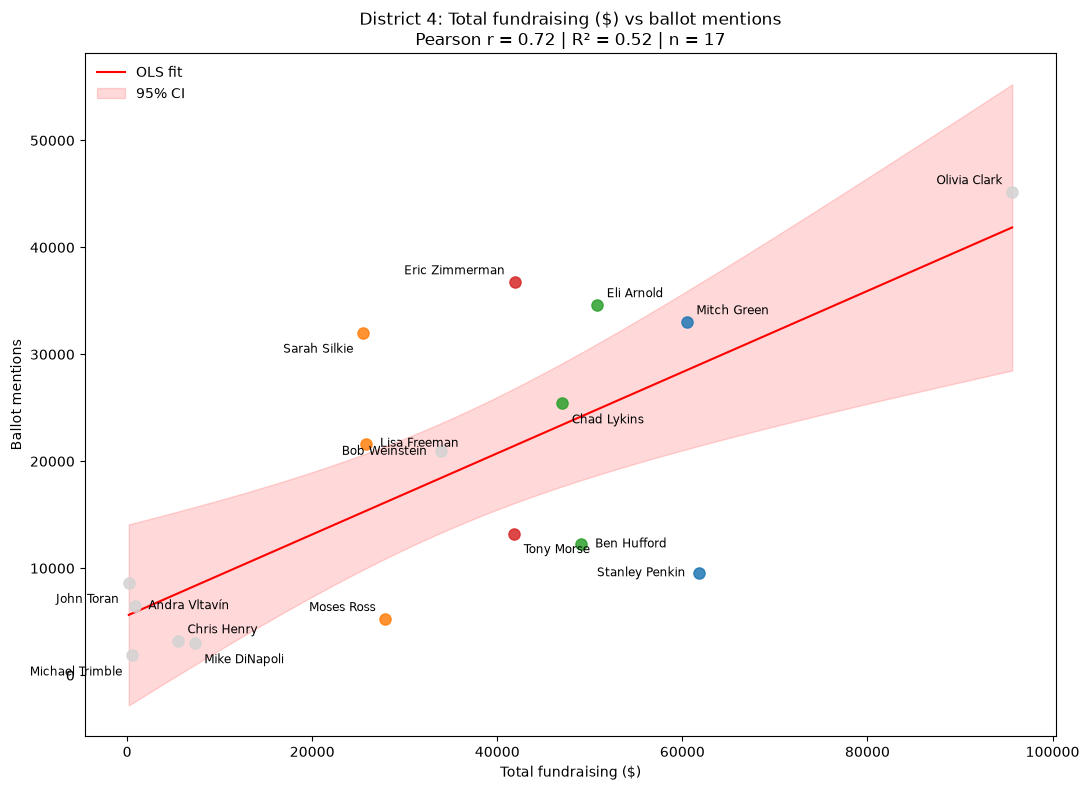

In [10]:
FIGURE_DIR = (
    ROOT
    / "outputs"
    / "figures"
    / "question_3"
    / "finance_metric_explorer"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


scope_for_file = (
    "all"
    if DISTRICT is None
    else f"d{DISTRICT}"
)


figure_path = (
    FIGURE_DIR
    / (
        f"{scope_for_file}_"
        f"{X_VARIABLE}_vs_mentions.png"
    )
)


title = (
    f"{scope_label}: "
    f"{x_label} vs ballot mentions"
)


model = OLSlinearRegression(
    x_data=plot_data[
        x_column
    ],
    y_data=plot_data[
        Y_VARIABLE
    ],
    x_label=x_label,
    y_label="Ballot mentions",
    title=title,
    save_name=(
        str(
            figure_path
        )
        if SAVE_FIGURE
        else ""
    ),
    colors=point_colors,
    names=plot_data[
        "canonical_candidate"
    ],
)


## 10. Read the regression result

These are the same basic quantities underlying the figure.

The coefficient tells us how the fitted number of mentions changes when X
increases by one unit.

**Be careful with units:**

- for total dollars, one unit means one dollar;
- for a share, one unit means moving from 0 to 1 (0% to 100%);
- R² is generally easier to compare across variables than the raw slope.


In [11]:
print(
    model.summary()
)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     16.35
Date:                Mon, 10 Aug 2026   Prob (F-statistic):            0.00106
Time:                        09:13:51   Log-Likelihood:                -179.48
No. Observations:                  17   AIC:                             363.0
Df Residuals:                      15   BIC:                             364.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5567.5547   3985.669      1.397      0.1

# 11. Which finance variable explains the most variation?

The graph above stays static and shows **one variable only**.

This section loops over all available finance variables and fits the same
simple OLS:

`mentions = a + b × finance metric`

It then ranks the variables by R² **within the currently selected district**.

This is useful for deciding which variable to inspect next.

### Important comparison caveat

`n` can differ across variables.

A high R² based on fewer candidates is not automatically more convincing than
a slightly lower R² based on a larger sample.


In [12]:
def screen_finance_metrics(
    data,
    metrics,
    district=None,
):
    if district is None:
        screen_data = data.copy()
        scope = "All districts"

    else:
        screen_data = data[
            data["district"].eq(
                district
            )
        ].copy()

        scope = (
            f"District {district}"
        )


    rows = []


    for metric_key, metric_info in metrics.items():
        column = metric_info[
            "column"
        ]


        model_data = screen_data[
            [
                column,
                "mentions",
            ]
        ].dropna()


        if (
            len(model_data) < 4
            or model_data[
                column
            ].nunique()
            < 2
        ):
            continue


        x = model_data[
            column
        ].to_numpy(
            dtype=float
        )

        y = model_data[
            "mentions"
        ].to_numpy(
            dtype=float
        )


        model = sm.OLS(
            y,
            sm.add_constant(
                x
            ),
        ).fit()


        pearson_r = (
            model_data[
                column
            ]
            .corr(
                model_data[
                    "mentions"
                ]
            )
        )


        rows.append(
            {
                "scope": scope,
                "metric": metric_key,
                "family": metric_info[
                    "family"
                ],
                "variable": metric_info[
                    "label"
                ],
                "n": int(
                    model.nobs
                ),
                "pearson_r": pearson_r,
                "r_squared": model.rsquared,
                "slope_p_value": model.pvalues[
                    1
                ],
            }
        )


    results = pd.DataFrame(
        rows
    )


    return (
        results
        .sort_values(
            "r_squared",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


metric_screen = screen_finance_metrics(
    analysis,
    METRICS,
    district=DISTRICT,
)


display(
    metric_screen.round(
        {
            "pearson_r": 3,
            "r_squared": 3,
            "slope_p_value": 4,
        }
    )
)


,scope,metric,family,variable,n,pearson_r,r_squared,slope_p_value
0,District 4,spending_total,Spending total,Total spending ($),19,0.815,0.664,0.0000
1,District 4,spending_count_mega,Spending bin count,Mega expenditure records,19,0.778,0.605,0.0001
2,District 4,spending_amount_mega,Spending bin amount,Mega spending amount ($),19,0.772,0.595,0.0001
3,District 4,spending_amount_large,Spending bin amount,Large spending amount ($),19,0.729,0.531,0.0004
4,District 4,fundraising_total,Fundraising total,Total fundraising ($),17,0.722,0.522,0.0011
5,District 4,fundraising_amount_small,Fundraising bin amount,Small contribution dollars ($),17,0.717,0.514,0.0012
6,District 4,fundraising_count_small,Fundraising bin count,Small contribution records,17,0.700,0.490,0.0018
7,District 4,fundraising_amount_micro,Fundraising bin amount,Micro contribution dollars ($),17,0.683,0.466,0.0025
8,District 4,spending_count_large,Spending bin count,Large expenditure records,19,0.672,0.452,0.0016
9,District 4,spending_count_medium,Spending bin count,Medium expenditure records,19,0.667,0.445,0.0018


## 12. A smaller top-results table

This is often the easiest table to discuss with the team.


In [13]:
display(
    metric_screen[
        [
            "metric",
            "family",
            "n",
            "pearson_r",
            "r_squared",
            "slope_p_value",
        ]
    ]
    .head(15)
    .round(
        {
            "pearson_r": 3,
            "r_squared": 3,
            "slope_p_value": 4,
        }
    )
)


,metric,family,n,pearson_r,r_squared,slope_p_value
0,spending_total,Spending total,19,0.815,0.664,0.0000
1,spending_count_mega,Spending bin count,19,0.778,0.605,0.0001
2,spending_amount_mega,Spending bin amount,19,0.772,0.595,0.0001
3,spending_amount_large,Spending bin amount,19,0.729,0.531,0.0004
4,fundraising_total,Fundraising total,17,0.722,0.522,0.0011
5,fundraising_amount_small,Fundraising bin amount,17,0.717,0.514,0.0012
6,fundraising_count_small,Fundraising bin count,17,0.700,0.490,0.0018
7,fundraising_amount_micro,Fundraising bin amount,17,0.683,0.466,0.0025
8,spending_count_large,Spending bin count,19,0.672,0.452,0.0016
9,spending_count_medium,Spending bin count,19,0.667,0.445,0.0018


## 13. How to use this notebook

The workflow is intentionally manual:

**First**
```python
DISTRICT = 4
X_VARIABLE = "fundraising_total"
```

Read the plot and the interesting candidate pairs.

**Then try**
```python
X_VARIABLE = "fundraising_amount_share_micro"
```

or

```python
X_VARIABLE = "fundraising_amount_large"
```

or

```python
X_VARIABLE = "spending_median"
```

and rerun.

The ranking table helps answer:

> **Which single finance dimension has the strongest univariate relationship
> with ballot mentions in this district?**

The candidate colors answer a different question:

> **Which candidates look financially similar on this dimension but have
> very different electoral support?**

Those are related, but they are not the same question.


## 14. Export the current metric screen and pair table


In [14]:
OUTPUT_DIR = (
    PROCESSED
    / "finance_analysis"
    / str(YEAR)
    / "question_3"
    / "static_metric_explorer"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


metric_screen.to_csv(
    OUTPUT_DIR
    / (
        f"{scope_for_file}_"
        "finance_metric_r2_screen.csv"
    ),
    index=False,
)


interesting_pairs.to_csv(
    OUTPUT_DIR
    / (
        f"{scope_for_file}_"
        f"{X_VARIABLE}_"
        "interesting_pairs.csv"
    ),
    index=False,
)


print(
    "SAVED:",
    OUTPUT_DIR,
)


SAVED: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/finance_analysis/2024/question_3/static_metric_explorer
